Install Required Library

In [ ]:
!pip install rasterio

Install Required Library

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

Define File Paths

In [ ]:
day_path = "/content/sdei-global-summer-lst-2013-day-max-asia.tif"
night_path = "/content/sdei-global-summer-lst-2013-night-min-asia.tif"

Read TIF Files

In [ ]:
with rasterio.open(day_path) as src_day:
    day = src_day.read(1).astype('float32')
    nodata_day = src_day.nodata

with rasterio.open(night_path) as src_night:
    night = src_night.read(1).astype('float32')
    nodata_night = src_night.nodata

Handle NoData Values

In [ ]:
if nodata_day is not None:
    day[day == nodata_day] = np.nan

if nodata_night is not None:
    night[night == nodata_night] = np.nan

Downsample Data

In [ ]:
factor = 4
day = day[::factor, ::factor]
night = night[::factor, ::factor]

Basic Visualization

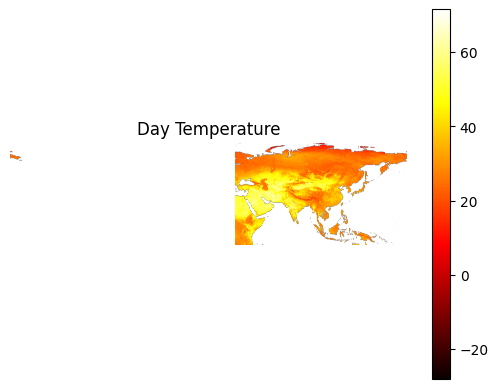

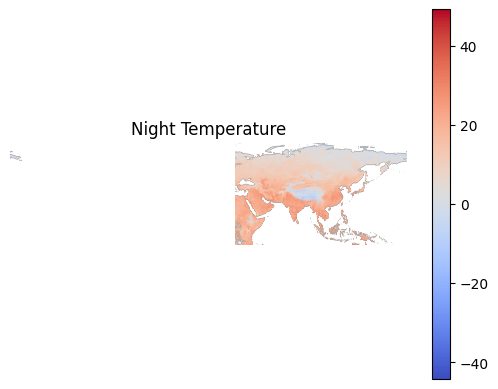

In [ ]:
plt.imshow(day, cmap='hot')
plt.title("Day Temperature")
plt.colorbar()
plt.axis('off')
plt.show()

plt.imshow(night, cmap='coolwarm')
plt.title("Night Temperature")
plt.colorbar()
plt.axis('off')
plt.show()

UHI Intensity Classification

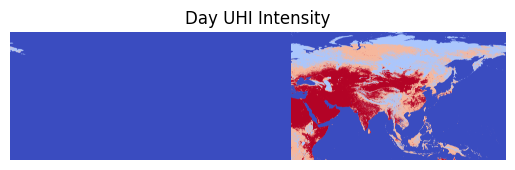

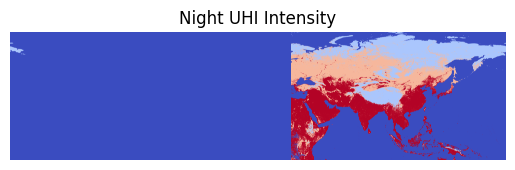

In [ ]:
def classify(data):
    out = np.zeros_like(data)
    p33 = np.nanpercentile(data, 33)
    p66 = np.nanpercentile(data, 66)
    out[data < p33] = 1
    out[(data >= p33) & (data < p66)] = 2
    out[data >= p66] = 3
    return out

day_intensity = classify(day)
night_intensity = classify(night)

plt.imshow(day_intensity, cmap='coolwarm')
plt.title("Day UHI Intensity")
plt.axis('off')
plt.show()

plt.imshow(night_intensity, cmap='coolwarm')
plt.title("Night UHI Intensity")
plt.axis('off')
plt.show()

Histogram Analysis

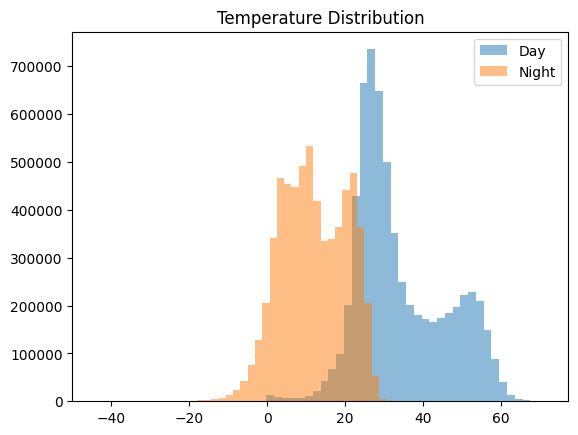

In [ ]:
plt.hist(day.flatten(), bins=50, alpha=0.5, label='Day')
plt.hist(night.flatten(), bins=50, alpha=0.5, label='Night')
plt.legend()
plt.title("Temperature Distribution")
plt.show()

Hotspot Detection

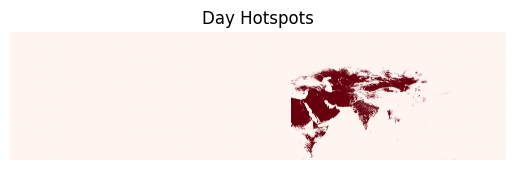

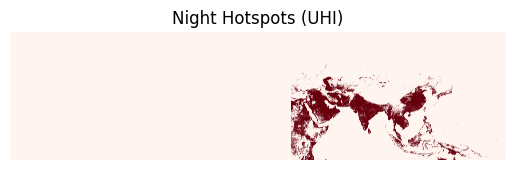

In [ ]:
day_thresh = np.nanpercentile(day, 75)
night_thresh = np.nanpercentile(night, 75)

day_hot = day > day_thresh
night_hot = night > night_thresh

plt.imshow(day_hot, cmap='Reds')
plt.title("Day Hotspots")
plt.axis('off')
plt.show()

plt.imshow(night_hot, cmap='Reds')
plt.title("Night Hotspots (UHI)")
plt.axis('off')
plt.show()

Temperature Difference Analysis

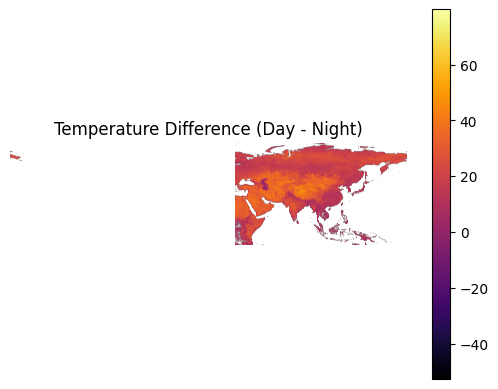

In [ ]:
dtd = day - night

plt.imshow(dtd, cmap='inferno')
plt.title("Temperature Difference (Day - Night)")
plt.colorbar()
plt.axis('off')
plt.show()

Difference Classification

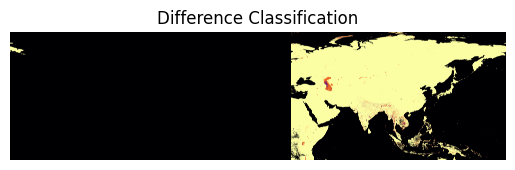

In [ ]:
diff_class = np.zeros_like(dtd)

diff_class[dtd < 2] = 1
diff_class[(dtd >= 2) & (dtd < 5)] = 2
diff_class[dtd >= 5] = 3

plt.imshow(diff_class, cmap='inferno')
plt.title("Difference Classification")
plt.axis('off')
plt.show()

Statistical Analysis

In [ ]:
print("---- DAY ----")
print("Max:", np.nanmax(day))
print("Min:", np.nanmin(day))
print("Mean:", np.nanmean(day))
print("Std:", np.nanstd(day))

print("\n---- NIGHT ----")
print("Max:", np.nanmax(night))
print("Min:", np.nanmin(night))
print("Mean:", np.nanmean(night))
print("Std:", np.nanstd(night))

print("\n---- DIFFERENCE ----")
print("Mean:", np.nanmean(dtd))

---- DAY ----
Max: 71.53
Min: -28.05
Mean: 34.096115
Std: 11.6037855

---- NIGHT ----
Max: 49.23
Min: -44.17
Mean: 11.917185
Std: 8.329482

---- DIFFERENCE ----
Mean: 22.278217


K-MEANS CLUSTERING

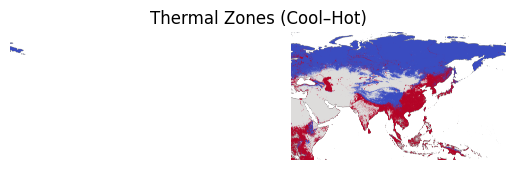


Cluster 0
Mean Day: 49.6303
Mean Night: 17.19432
Mean Diff: 32.435978

Cluster 1
Mean Day: 25.989092
Mean Night: 5.1994095
Mean Diff: 20.789692

Cluster 2
Mean Day: 31.48352
Mean Night: 19.973642
Mean Diff: 11.509868
Cluster 0 Area %: 29.6797760459819
Cluster 1 Area %: 49.11157520768178
Cluster 2 Area %: 21.208648746336316


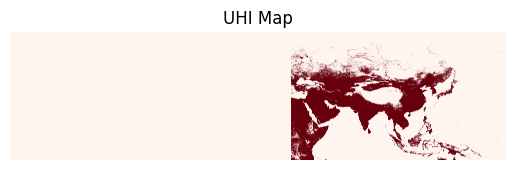

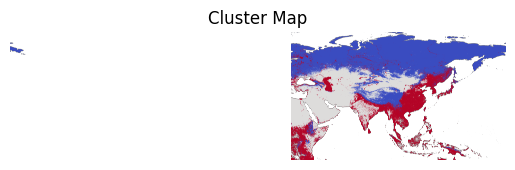

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Prepare features
X = np.stack([day.flatten(), night.flatten(), dtd.flatten()], axis=1)

# Remove NaN
mask = ~np.isnan(X).any(axis=1)
X_clean = X[mask]

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_clean)

# Convert back to image
cluster_map = np.full(day.size, np.nan)
cluster_map[mask] = labels
cluster_map = cluster_map.reshape(day.shape)

# -------------------------------
# Label clusters (Cool–Hot)
# -------------------------------
means = []
for i in range(3):
    m = np.nanmean(night[cluster_map == i])
    means.append((i, m))

means.sort(key=lambda x: x[1])

labels_map = {
    means[0][0]: 0,
    means[1][0]: 1,
    means[2][0]: 2
}

labeled_clusters = np.full(cluster_map.shape, np.nan)

for k, v in labels_map.items():
    labeled_clusters[cluster_map == k] = v

labeled_clusters = labeled_clusters.astype(float)

# -------------------------------
# Visualization
# -------------------------------
plt.imshow(labeled_clusters, cmap='coolwarm')
plt.title("Thermal Zones (Cool–Hot)")
plt.axis('off')
plt.show()

# -------------------------------
# Cluster Statistics
# -------------------------------
for i in range(3):
    print(f"\nCluster {i}")
    print("Mean Day:", np.nanmean(day[cluster_map == i]))
    print("Mean Night:", np.nanmean(night[cluster_map == i]))
    print("Mean Diff:", np.nanmean(dtd[cluster_map == i]))

# -------------------------------
# Area Percentage
# -------------------------------
total = np.sum(~np.isnan(cluster_map))
for i in range(3):
    area = np.sum(cluster_map == i)
    print(f"Cluster {i} Area %:", (area / total) * 100)

# -------------------------------
# Compare with UHI
# -------------------------------
uhi = night > np.nanmean(night)

plt.imshow(uhi, cmap='Reds')
plt.title("UHI Map")
plt.axis('off')
plt.show()

plt.imshow(labeled_clusters, cmap='coolwarm')
plt.title("Cluster Map")
plt.axis('off')
plt.show()

Cooling Efficiency Map

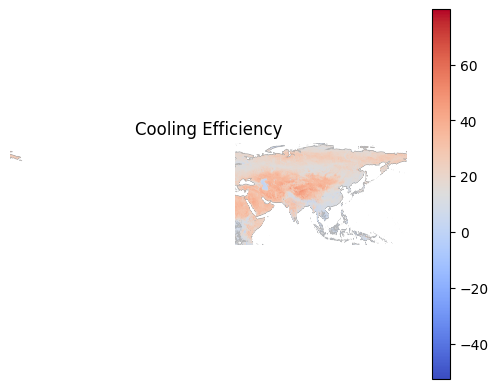

In [ ]:
cooling = dtd

plt.imshow(cooling, cmap='coolwarm')
plt.title("Cooling Efficiency")
plt.colorbar()
plt.axis('off')
plt.show()

Heat Risk Zones

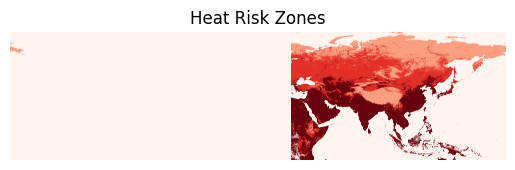

In [ ]:
risk = np.zeros_like(night)

p33 = np.nanpercentile(night, 33)
p66 = np.nanpercentile(night, 66)

risk[night < p33] = 1
risk[(night >= p33) & (night < p66)] = 2
risk[night >= p66] = 3

plt.imshow(risk, cmap='Reds')
plt.title("Heat Risk Zones")
plt.axis('off')
plt.show()

Future Heat Risk

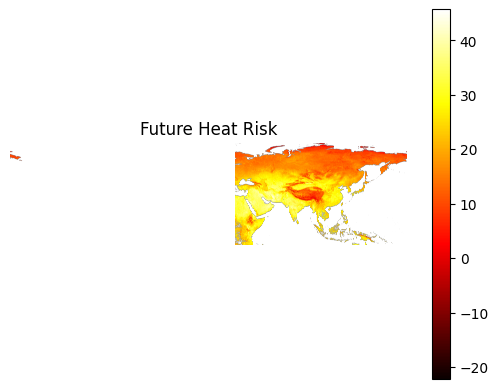

In [ ]:
future_risk = (0.6 * night) + (0.4 * day)

plt.imshow(future_risk, cmap='hot')
plt.title("Future Heat Risk")
plt.colorbar()
plt.axis('off')
plt.show()

Machine Learning Prediction

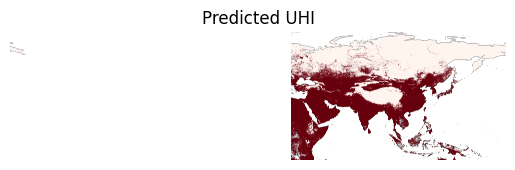

In [39]:
from sklearn.ensemble import RandomForestClassifier

X = np.stack([day.flatten(), night.flatten(), dtd.flatten()], axis=1)
y = (night.flatten() > np.nanmean(night)).astype(int)

mask = ~np.isnan(X).any(axis=1)
X = X[mask]
y = y[mask]

model = RandomForestClassifier(n_estimators=10)
model.fit(X, y)

y_pred = model.predict(X)

pred_map = np.full(day.size, np.nan)
pred_map[mask] = y_pred
pred_map = pred_map.reshape(day.shape)

plt.imshow(pred_map, cmap='Reds')
plt.title("Predicted UHI")
plt.axis('off')
plt.show()